In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
import numpy as np

In [2]:
# -------------------------------
# Data Utilities
# -------------------------------

def load_dakshina_data(file_path):
    input_texts, target_texts = [], []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 3:
                hindi_word, latin_input, _ = parts
                input_texts.append(latin_input.lower())
                target_texts.append(hindi_word)
    return input_texts, target_texts

def create_vocab(texts, special_tokens=[]):
    vocab = sorted(set("".join(texts)))
    stoi = {ch: i + len(special_tokens) for i, ch in enumerate(vocab)}
    for i, tok in enumerate(special_tokens):
        stoi[tok] = i
    itos = {i: ch for ch, i in stoi.items()}
    return stoi, itos

def encode(text, stoi):
    return [stoi[c] for c in text]

def collate_fn(batch, pad_idx):
    inputs, targets = zip(*batch)
    inputs = [torch.tensor(seq, dtype=torch.long) for seq in inputs]
    targets = [torch.tensor(seq, dtype=torch.long) for seq in targets]
    inputs_padded = pad_sequence(inputs, padding_value=pad_idx, batch_first=True)
    targets_padded = pad_sequence(targets, padding_value=pad_idx, batch_first=True)
    return inputs_padded, targets_padded

In [3]:
# -------------------------------
# Model Definition
# -------------------------------

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=0)
        self.rnn = nn.GRU(emb_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, hidden = self.rnn(embedded)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))).unsqueeze(0)
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.attn = nn.Linear(hidden_size * 3, hidden_size)  # fixed
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        batch_size, seq_len, _ = encoder_outputs.shape

        # hidden: (1, B, H) → (B, 1, H) → (B, S, H)
        hidden = hidden.permute(1, 0, 2).repeat(1, seq_len, 1)

        # encoder_outputs: (B, S, H*2)
        combined = torch.cat((hidden, encoder_outputs), dim=2)  # (B, S, H*3)
        energy = torch.tanh(self.attn(combined))  # (B, S, H)
        attention = self.v(energy).squeeze(2)     # (B, S)
        return torch.softmax(attention, dim=1)    # (B, S)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size, padding_idx=0)
        self.rnn = nn.GRU(emb_size + hidden_size * 2, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.attention = Attention(hidden_size)

    def forward(self, x, hidden, encoder_outputs):
        embedded = self.embedding(x).unsqueeze(1)
        attn_weights = self.attention(hidden, encoder_outputs).unsqueeze(1)
        context = torch.bmm(attn_weights, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

In [4]:
# -------------------------------
# Training Loop
# -------------------------------

def train_model(encoder, decoder, data, optimizer, criterion, epochs=10, pad_idx=0, sos_idx=1):
    for epoch in range(epochs):
        total_loss = 0
        for input_batch, target_batch in data:
            optimizer.zero_grad()
            encoder_outputs, hidden = encoder(input_batch)
            batch_size, tgt_len = target_batch.size()

            dec_input = torch.full((batch_size,), sos_idx, dtype=torch.long)
            loss = 0

            for t in range(1, tgt_len):
                output, hidden = decoder(dec_input, hidden, encoder_outputs)
                loss += criterion(output, target_batch[:, t])
                dec_input = target_batch[:, t]  # Teacher forcing

            loss.backward()
            optimizer.step()
            total_loss += loss.item() / tgt_len
        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [5]:
# -------------------------------
# Main
# -------------------------------

file_path = 'dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.train.tsv'
input_texts, target_texts = load_dakshina_data(file_path)

eos_token = '␃'
sos_token = '␂'
target_texts = [sos_token + t + eos_token for t in target_texts]

input_stoi, input_itos = create_vocab(input_texts, special_tokens=['<pad>'])
target_stoi, target_itos = create_vocab(target_texts, special_tokens=['<pad>', sos_token, eos_token])

pad_idx = target_stoi['<pad>']
sos_idx = target_stoi[sos_token]

data_pairs = [(encode(inp, input_stoi), encode(tgt, target_stoi)) for inp, tgt in zip(input_texts, target_texts)]
data_loader = torch.utils.data.DataLoader(data_pairs, batch_size=32, shuffle=True,
                                          collate_fn=lambda b: collate_fn(b, pad_idx))

# Model init
input_vocab_size = len(input_stoi)
target_vocab_size = len(target_stoi)
encoder = Encoder(input_vocab_size, emb_size=64, hidden_size=256)
decoder = Decoder(target_vocab_size, emb_size=64, hidden_size=256)

In [ ]:
# Optimizer and loss
params = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(params, lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

# Train
train_model(encoder, decoder, data_loader, optimizer, criterion, epochs=30, pad_idx=pad_idx, sos_idx=sos_idx)

# Save
torch.save({
    'encoder_state': encoder.state_dict(),
    'decoder_state': decoder.state_dict(),
    'input_stoi': input_stoi,
    'target_stoi': target_stoi,
    'input_itos': input_itos,
    'target_itos': target_itos
}, 'transliteration_model_v2.pth')


In [6]:
# Load checkpoint
checkpoint = torch.load('../../transliteration_model_v2.pth', map_location='cpu')

# Restore vocab
input_stoi = checkpoint['input_stoi']
target_stoi = checkpoint['target_stoi']
input_itos = checkpoint['input_itos']
target_itos = checkpoint['target_itos']

# Match model architecture used during training
input_vocab_size = len(input_stoi)
target_vocab_size = len(target_stoi)
emb_size = 64
hidden_size = 256

# Rebuild model
encoder = Encoder(input_vocab_size, emb_size=emb_size, hidden_size=hidden_size)
decoder = Decoder(target_vocab_size, emb_size=emb_size, hidden_size=hidden_size)

# Load trained weights
encoder.load_state_dict(checkpoint['encoder_state'])
decoder.load_state_dict(checkpoint['decoder_state'])

# Evaluation mode
encoder.eval()
decoder.eval()

Decoder(
  (embedding): Embedding(66, 64, padding_idx=0)
  (rnn): GRU(576, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=66, bias=True)
  (attention): Attention(
    (attn): Linear(in_features=768, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
)

In [9]:
def predict(word, encoder, decoder, input_stoi, target_itos, target_stoi, max_len=20):
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
        # Encode input
        input_tensor = torch.tensor([input_stoi.get(c, 0) for c in word], dtype=torch.long).unsqueeze(0)  # [1, seq_len]
        encoder_outputs, hidden = encoder(input_tensor)

        # Start decoding with <sos>
        sos_token = '␂'
        eos_token = '␃'
        input_token = torch.tensor([target_stoi[sos_token]], dtype=torch.long)  # [batch_size]

        output = []
        for _ in range(max_len):
            logits, hidden = decoder(input_token, hidden, encoder_outputs)
            next_token = logits.argmax(-1).item()
            char = target_itos.get(next_token, '')

            if char == eos_token:
                break

            output.append(char)
            input_token = torch.tensor([next_token], dtype=torch.long)

        return ''.join(output)


In [ ]:
!pip install matplotlib
!pip install seaborn

Character-level Accuracy:     0.6898
Word-level Accuracy:          0.3407
Average BLEU Score:           0.5594


C:\Users\Dell\AppData\Local\Temp\ipykernel_22540\530355761.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")


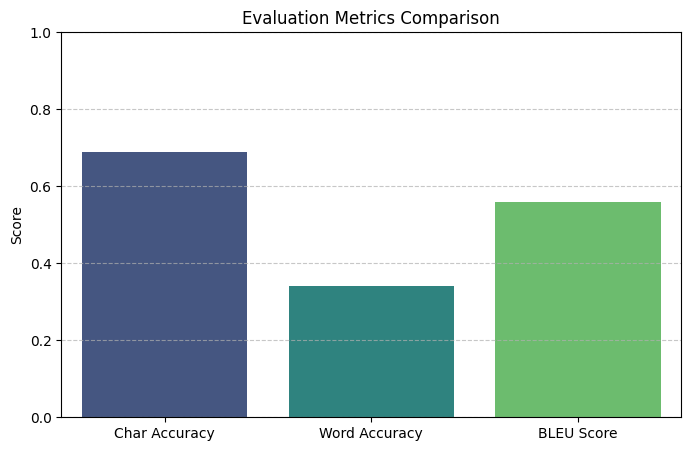

In [16]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from difflib import SequenceMatcher

# -----------------------------
# Load Dakshina test data
# -----------------------------
test_file = "dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.test.tsv"
df = pd.read_csv(test_file, sep="\t", header=None, names=["hi", "latin", "freq"])
true_outputs = df["hi"].tolist()
input_sequences = df["latin"].tolist()

# -----------------------------
# Predict all words
# -----------------------------
pred_outputs = [predict(word, encoder, decoder, input_stoi, target_itos, target_stoi) for word in input_sequences]

# -----------------------------
# Evaluation Metrics
# -----------------------------
def character_level_accuracy(true, pred):
    total_chars = 0
    correct_chars = 0
    for t, p in zip(true, pred):
        min_len = min(len(t), len(p))
        correct_chars += sum(1 for i in range(min_len) if t[i] == p[i])
        total_chars += len(t)
    return correct_chars / total_chars if total_chars > 0 else 0

def word_level_accuracy(true, pred):
    correct = sum(t == p for t, p in zip(true, pred))
    return correct / len(true) if true else 0

def average_bleu_score(true, pred):
    smoothie = SmoothingFunction().method4
    scores = [sentence_bleu([list(t)], list(p), smoothing_function=smoothie) for t, p in zip(true, pred)]
    return sum(scores) / len(scores)

# -----------------------------
# Compute Results
# -----------------------------
char_acc = character_level_accuracy(true_outputs, pred_outputs)
word_acc = word_level_accuracy(true_outputs, pred_outputs)
bleu = average_bleu_score(true_outputs, pred_outputs)

print(f"Character-level Accuracy:     {char_acc:.4f}")
print(f"Word-level Accuracy:          {word_acc:.4f}")
print(f"Average BLEU Score:           {bleu:.4f}")

# -----------------------------
# Plot Bar Chart of Metrics
# -----------------------------
metrics = {
    "Char Accuracy": char_acc,
    "Word Accuracy": word_acc,
    "BLEU Score": bleu
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")
plt.ylim(0, 1)
plt.title("Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [17]:
test_word = "department"
prediction = predict(test_word, encoder, decoder, input_stoi, target_itos, target_stoi)
print(f"{test_word} → {prediction}")

department → डिपार्टमेंट
